In [1]:
!uv pip install polars
!uv pip install scikit-learn

Audited 1 package in 42ms
Audited 1 package in 122ms


In [2]:
import json
from pathlib import Path
import librosa
import polars
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm.notebook import tqdm
import random
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle as sk_shuffle
from sklearn.pipeline import Pipeline

## Paths

In [3]:
# SONICS_BASE_PATH = Path("/mnt/data/kusnierz/audio-data/Sonics")
SONICS_BASE_PATH = Path("/net/people/plgrid/plgjedrzejkusnierz/scratch/data/Sonics")
DATA_BASE_PATH = SONICS_BASE_PATH / "all_data"
DATA = SONICS_BASE_PATH / "all_data_16k_mono"
METADATA = DATA_BASE_PATH / "metadata.json"
cache_dir = SONICS_BASE_PATH / "cache"
cache_dir.mkdir(exist_ok=True)

In [4]:
fake_csv = SONICS_BASE_PATH / "fake_songs.csv"
real_csv = SONICS_BASE_PATH / "real_songs.csv"

In [5]:
train = SONICS_BASE_PATH / "train.csv"
test = SONICS_BASE_PATH / "test.csv"
valid = SONICS_BASE_PATH / "valid.csv"

In [6]:
# embedds_path = SONICS_BASE_PATH / "preprocessed"
embedds_path = SONICS_BASE_PATH / "preprocessed_16k_mono"
mert = embedds_path / "mert"
w2v = embedds_path / "wav2vec"

In [7]:
# 1. Get list of files
mert_files = sorted(list(mert.glob("*.npy")))
# Assuming wav2vec files have same names
w2v_files = sorted(list(w2v.glob("*.npy")))

print(f"Found {len(mert_files)} MERT files")
print(f"Found {len(w2v_files)} Wav2Vec files")

Found 93215 MERT files
Found 93215 Wav2Vec files


In [8]:
df_fake = pd.read_csv(fake_csv).fillna("")
df_real = pd.read_csv(real_csv).fillna("")

/net/afscra/people/plgjedrzejkusnierz/slurm_jobdir/19809964/tmp.ac0380/ipykernel_52530/2460913627.py:1: DtypeWarning: Columns (9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fake = pd.read_csv(fake_csv).fillna("")


In [9]:
with open(METADATA, 'r') as f:
    metadata = json.load(f)

df_meta = pd.DataFrame(metadata)
df_meta['duration'] = pd.to_numeric(df_meta['duration'], errors='coerce')

## Base metadata checks

In [4]:
expected_fake = df_fake.groupby('split').size().to_dict()  # deepfake per split
expected_real = df_real.groupby('split').size().to_dict()  # bonafide per split

print("Expected deepfake (fake_songs.csv):")
for split, count in expected_fake.items():
    print(f"  {split}: {count}")
print(f"Total deepfake: {sum(expected_fake.values())}")

print("\nExpected bonafide (real_songs.csv):")
for split, count in expected_real.items():
    print(f"  {split}: {count}")
print(f"Total bonafide: {sum(expected_real.values())}")

# Actual counts from metadata
actual_counts = {}
for entry in metadata:
    split = entry.get('set', 'unknown')
    spoof = entry.get('spoof', 'unknown')
    if split not in actual_counts:
        actual_counts[split] = Counter()
    actual_counts[split][spoof] += 1

print("\nActual downloaded (metadata.json):")
total_actual = 0
for split, counts in actual_counts.items():
    print(f"  {split}: {dict(counts)}")
    total_actual += sum(counts.values())
print(f"Total downloaded: {total_actual}")

# Comparison
print("\nComparison per split:")
all_splits = set(expected_fake.keys()) | set(expected_real.keys()) | set(actual_counts.keys())
for split in sorted(all_splits):
    exp_deep = expected_fake.get(split, 0)
    exp_bona = expected_real.get(split, 0)
    act = actual_counts.get(split, Counter())
    act_deep = act.get('deepfake', 0)
    act_bona = act.get('bonafide', 0)
    print(f"  {split}: Expected deepfake {exp_deep}, bonafide {exp_bona}; Actual deepfake {act_deep}, bonafide {act_bona}")

/tmp/ipykernel_398019/1146244192.py:4: DtypeWarning: Columns (9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fake = pd.read_csv(fake_csv).fillna("")


Expected deepfake (fake_songs.csv):
  test: 12778
  train: 34023
  valid: 2273
Total deepfake: 49074

Expected bonafide (real_songs.csv):
  test: 13237
  train: 32686
  valid: 2167
Total bonafide: 48090

Actual downloaded (metadata.json):
  train: {'deepfake': 34023, 'bonafide': 30032}
  test: {'deepfake': 12778, 'bonafide': 12127}
  valid: {'deepfake': 2273, 'bonafide': 1988}
Total downloaded: 93221

Comparison per split:
  test: Expected deepfake 12778, bonafide 13237; Actual deepfake 12778, bonafide 12127
  train: Expected deepfake 34023, bonafide 32686; Actual deepfake 34023, bonafide 30032
  valid: Expected deepfake 2273, bonafide 2167; Actual deepfake 2273, bonafide 1988


Total entries: 93221

Spoof types:
spoof
deepfake    49074
bonafide    44147
Name: count, dtype: int64

Sets:
set
train    64055
test     24905
valid     4261
Name: count, dtype: int64

Labels:
label
mostly fake    40769
half fake       6132
full fake       2173
Name: count, dtype: int64

Algorithms:
algorithm
chirp-v3.5            19057
udio-120s             18745
udio-30s               4903
chirp-v3               4285
chirp-v2-xxl-alpha     2084
Name: count, dtype: int64

Moods (top 10):
mood
                46901
disenchanted       44
whimsical          42
amused             42
confident          42
optimistic         41
powerless          41
energetic          40
hateful            39
regretful          37
Name: count, dtype: int64

Topics (top 10):
topic
                                       46901
overcoming adversity                      15
stone age (history)                       15
convolution vs transformer (AI)           15
notre dame cathedral (architecture)       14
alber

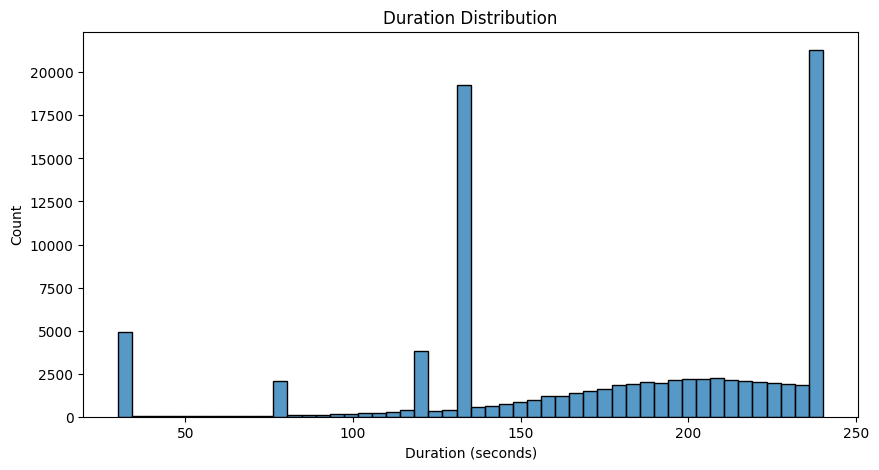

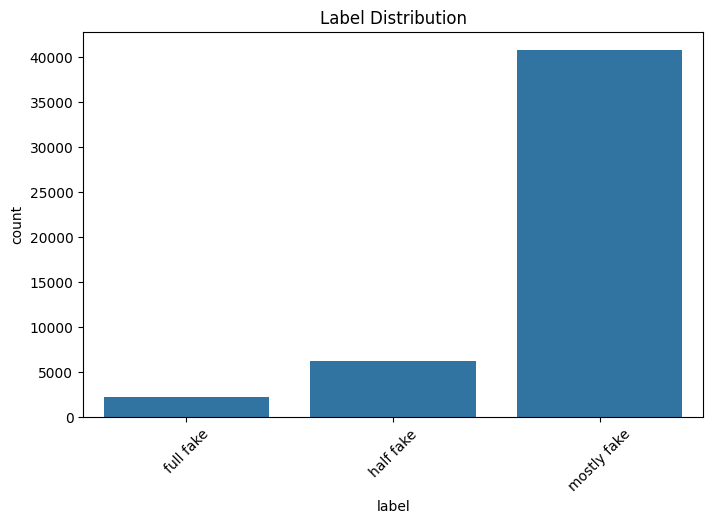

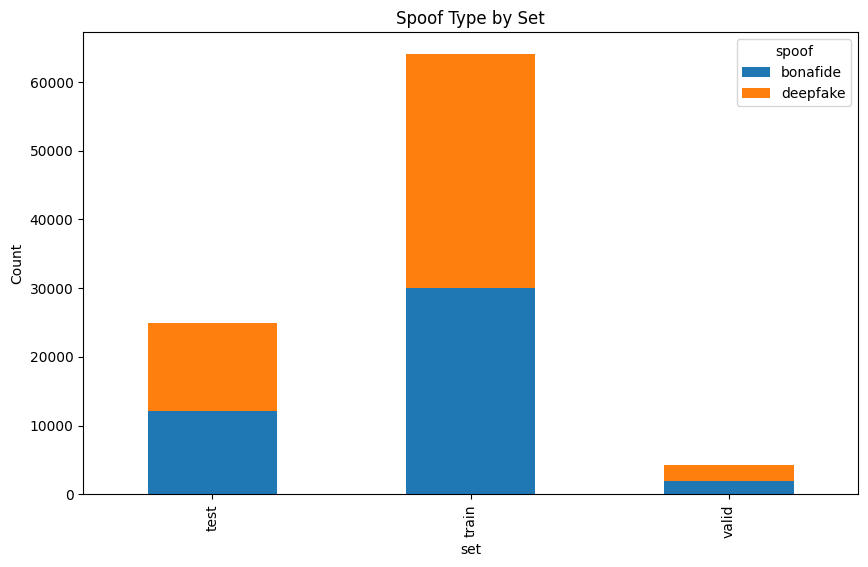

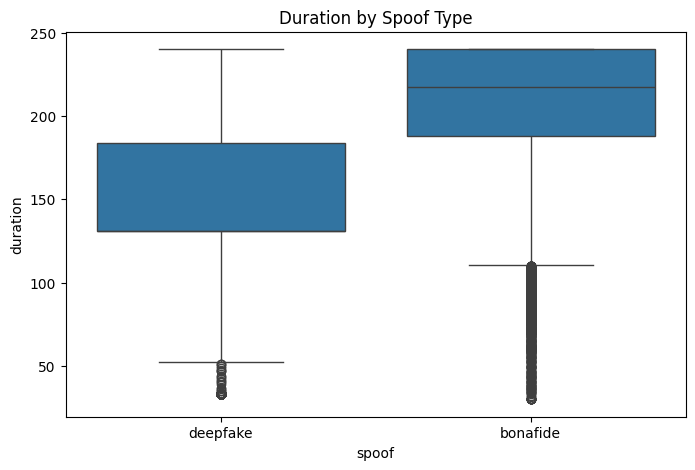

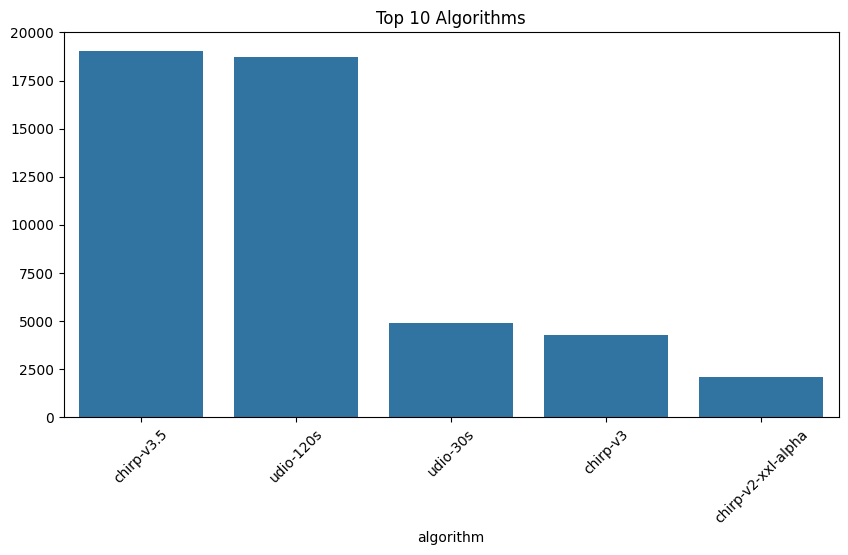

In [5]:
print("Total entries:", len(df_meta))
print("\nSpoof types:")
print(df_meta['spoof'].value_counts())

print("\nSets:")
print(df_meta['set'].value_counts())

print("\nLabels:")
print(df_meta['label'].value_counts())

print("\nAlgorithms:")
print(df_meta['algorithm'].value_counts())

print("\nMoods (top 10):")
print(df_meta['mood'].value_counts().head(10))

print("\nTopics (top 10):")
print(df_meta['topic'].value_counts().head(10))

# Duration analysis
print("\nDuration stats:")
print(df_meta['duration'].describe())

# Plot duration histogram
plt.figure(figsize=(10,5))
sns.histplot(df_meta['duration'].dropna(), bins=50)
plt.title('Duration Distribution')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.show()

# Label distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df_meta, x='label')
plt.title('Label Distribution')
plt.xticks(rotation=45)
plt.show()

# Spoof by set
spoof_by_set = df_meta.groupby(['set', 'spoof']).size().unstack(fill_value=0)
spoof_by_set.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Spoof Type by Set')
plt.ylabel('Count')
plt.show()

# Duration by spoof
plt.figure(figsize=(8,5))
sns.boxplot(data=df_meta, x='spoof', y='duration')
plt.title('Duration by Spoof Type')
plt.show()

top_alg = df_meta['algorithm'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_alg.index, y=top_alg.values)
plt.title('Top 10 Algorithms')
plt.xticks(rotation=45)
plt.show()

In [6]:
df_meta.head()

,dataset,filename,filepath,set,duration,bit_rate,topic,style,label,lyrics,algorithm,mood,spoof,original_filename,youtube_id,year,artist_overlap,title,singer,url
0,Sonics,train_fake_53884_suno_0_suno_new age_deepfake....,/mnt/data/kusnierz/audio-data/Sonics/all_data/...,train,240.084,34616.0,friendship,"male vocals, new age, piano, synthesizers, slo...",full fake,"[Verse 1]\nIn the quiet of the night, shadows ...",chirp-v3.5,anxious,deepfake,fake_53884_suno_0,NaN,NaN,NaN,NaN,NaN,NaN
1,Sonics,test_fake_53889_suno_0_suno_dance_deepfake.flac,/mnt/data/kusnierz/audio-data/Sonics/all_data/...,test,80.100,39938.0,python vs c++ (programming),"male vocals, electronic, synthesizers, fast te...",full fake,"[Intro]\n(Yeah, come on)\nPython, C++, let's d...",chirp-v2-xxl-alpha,inspired,deepfake,fake_53889_suno_0,NaN,NaN,NaN,NaN,NaN,NaN
2,Sonics,train_fake_53866_suno_1_suno_disco_deepfake.flac,/mnt/data/kusnierz/audio-data/Sonics/all_data/...,train,240.084,36388.0,king arthur (legend),"male vocals, synthesizers, bass, disco, energe...",full fake,"[Intro]\n(Trapped in the rhythm, oh yeah)\n[Ve...",chirp-v3.5,trapped,deepfake,fake_53866_suno_1,NaN,NaN,NaN,NaN,NaN,NaN
3,Sonics,test_fake_53883_suno_0_suno_smooth jazz_deepfa...,/mnt/data/kusnierz/audio-data/Sonics/all_data/...,test,120.096,36659.0,hercules (myth),"male vocals, saxophone, piano, double bass, sl...",full fake,[Intro]\n(Instrumental saxophone solo)\n[Verse...,chirp-v3,enchanted,deepfake,fake_53883_suno_0,NaN,NaN,NaN,NaN,NaN,NaN
4,Sonics,test_fake_53849_suno_0_suno_r&b_deepfake.flac,/mnt/data/kusnierz/audio-data/Sonics/all_data/...,test,80.100,42358.0,dead sea (geography),"male vocals, r&b, piano, guitar, slow tempo, d...",full fake,"[Verse 1]\nIn the heart of the desert, where t...",chirp-v2-xxl-alpha,determined,deepfake,fake_53849_suno_0,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'Deepfake')

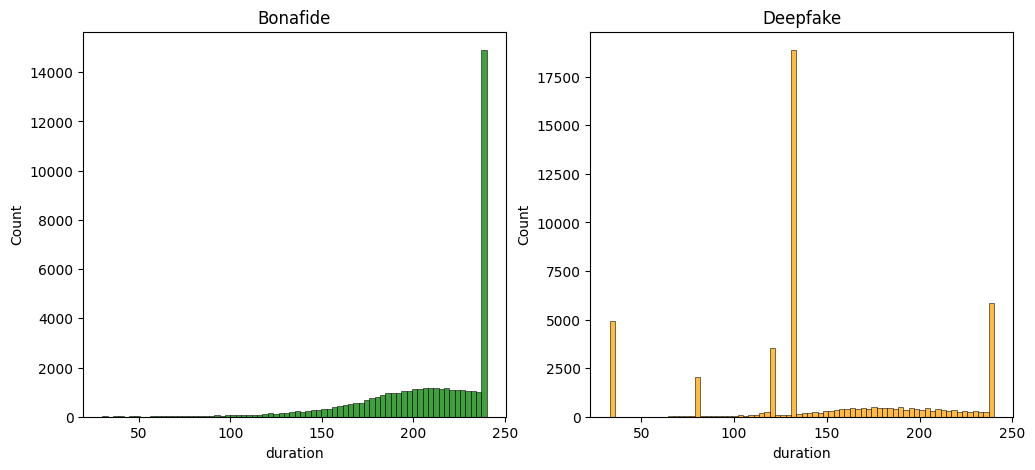

In [17]:
df_just_bf = df_meta[df_meta['spoof'] == "bonafide"]
df_just_df = df_meta[df_meta['spoof'] == "deepfake"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_just_bf, x='duration', color='green')
plt.title("Bonafide")

plt.subplot(1, 2, 2)
sns.histplot(df_just_df, x='duration', color='orange')
plt.title("Deepfake")


In [7]:
df_meta['spoof'].value_counts()

spoof
deepfake    49074
bonafide    44147
Name: count, dtype: int64

In [22]:
print(df_meta['bit_rate'].dtype)

object


In [23]:
print(df_meta['bit_rate'].isna().sum())

44147


In [18]:
print(df_meta['bit_rate'].notna().sum())

49074


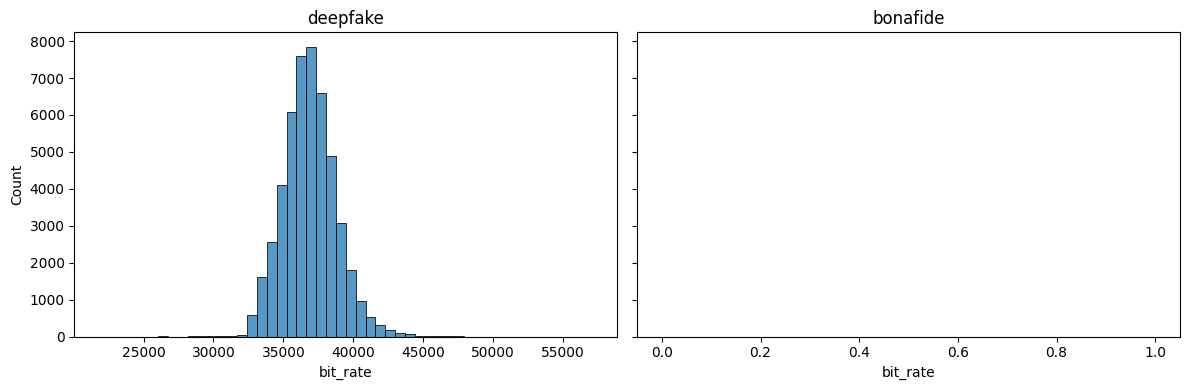

In [31]:
df_meta['bit_rate'] = pd.to_numeric(df_meta['bit_rate'], errors='coerce')

df1 = df_meta[df_meta["spoof"] == "deepfake"]
df2 = df_meta[df_meta["spoof"] == "bonafide"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.histplot(data=df1, x="bit_rate", bins=50, ax=ax[0])
ax[0].set_title("deepfake")

sns.histplot(data=df2, x="bit_rate", bins=50, ax=ax[1])
ax[1].set_title("bonafide")

plt.tight_layout()
plt.show()


### Train, Val, Test

In [10]:
df = polars.read_csv(train)

In [11]:
df.filter(df['artist_overlap'].is_not_null())

id,lyrics,algorithm,style,filename,bit_rate,duration,source,lyrics_feature,topic,genre,mood,label,filepath,target,skip_time,no_vocal,split,title,artist,year,youtube_id,artist_overlap
i64,str,str,str,str,f64,f64,str,str,str,str,str,str,str,i64,f64,bool,str,str,str,str,str,str
693,"""[Intro] [Verse 1] Now here yo…",null,null,"""real_00693""",41017.0,240.084,"""youtube""",null,null,null,null,"""real""","""real_songs/real_00693.mp3""",0,21.327219,false,"""train""","""Dreams""","""Fleetwood Mac""","""1977.0""","""5oWyMakvQew""","""False"""
1164,"""[Intro] (spoken) ""Alright guys…",null,null,"""real_01164""",37845.0,231.372,"""youtube""",null,null,null,null,"""real""","""real_songs/real_01164.mp3""",0,15.522219,false,"""train""","""Mine Diamonds""","""MineCraft Awesome Parodys""","""2016.0""","""dgha9S39Y6M""","""True"""
1318,"""[Intro] Fuck [Verse 1] Listen…",null,null,"""real_01318""",38548.0,240.084,"""youtube""",null,null,null,null,"""real""","""real_songs/real_01318.mp3""",0,86.498469,false,"""train""","""The Chain""","""Fleetwood Mac""","""1977.0""","""iLC-tHvkNvI""","""False"""
1409,"""[Intro] Gun 'em down (Gun 'em …",null,null,"""real_01409""",40107.0,193.428,"""youtube""",null,null,null,null,"""real""","""real_songs/real_01409.mp3""",0,0.891594,false,"""train""","""Armed and Dangerous""","""Juice WRLD""","""2018.0""","""cr82wSBZeeQ""","""True"""
1683,"""[Intro: Barbie & Ken] Hiya, Ba…",null,null,"""real_01683""",38869.0,201.168,"""youtube""",null,null,null,null,"""real""","""real_songs/real_01683.mp3""",0,9.025344,false,"""train""","""Barbie Girl""","""Aqua""","""1997.0""","""J-ii-82fsw8""","""False"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
52530,"""[Verse 1] Shut up lotus auto E…",null,null,"""real_52530""",34070.0,167.472,"""youtube""",null,null,null,null,"""real""","""real_songs/real_52530.mp3""",0,60.224094,false,"""train""","""Fuck Puppet""","""Machine Girl""","""2018.0""","""9m5o4vJdXP0""","""True"""
52716,"""[Verse 1] All the girls all da…",null,null,"""real_52716""",35480.0,197.604,"""youtube""",null,null,null,null,"""real""","""real_songs/real_52716.mp3""",0,11.809719,false,"""train""","""Red Clay Halo""","""Gillian Welch""","""2001.0""","""b2Ib4eIbAqE""","""False"""
52952,"""[Verse 1] One bad night I’ll h…",null,null,"""real_52952""",36636.0,194.868,"""youtube""",null,null,null,null,"""real""","""real_songs/real_52952.mp3""",0,5.160969,false,"""train""","""Every Night My Teeth Are Falli…","""The Antlers""","""2011.0""","""g3KAstxRIZk""","""False"""


In [ ]:
print(f"Current torch version: {torch.__version__} (Not used for loading .npy files)")
print(f"Current numpy version: {np.__version__}")

Current torch version: 2.9.1+cu128 (Not used for loading .npy files)
Current numpy version: 2.3.5


In [14]:
def load_and_visualize(file_list, model_name="Model", limit=2000):
    features = []
    labels = []
    
    print(f"Loading {model_name} data (max {limit} samples)...")
    
    # Shuffle list inside to get random distribution if limiting
    files_to_process = list(file_list)
    random.seed(42)
    random.shuffle(files_to_process)
    files_to_process = files_to_process[:limit]
    
    for p in tqdm(files_to_process, desc=f"Loading {model_name}"):
        # Determine label
        if "bonafide" in p.name:
            label = 0 # encoded as 0
        elif "deepfake" in p.name or "spoof" in p.name:
            label = 1 # encoded as 1
        else:
            continue
            
        try:
            # Load numpy array directly
            t = np.load(str(p))
            
            # Average Pooling over time to get single vector [Dim]
            if t.ndim == 2:
                # Global Mean Pooling
                # t shape: [seq_len, hidden_dim]
                emb = np.mean(t, axis=0)
                features.append(emb)
                labels.append(label) # <--- FIXED: Appending labels matched with features
        except Exception as e:
            # print(f"Failed {p.name}: {e}")
            pass
            
    X = np.array(features)
    y = np.array(labels, dtype=int)
    
    if len(X) == 0:
        print("No data found. Did you re-run the preprocessing script?")
        return

    print(f"--- Data Diagnostics for {model_name} ---")
    print(f"Data shape: {X.shape}")
    print(f"Labels shape: {y.shape}")
    if len(y) > 0:
        print(f"Class distribution: {np.bincount(y)} (0=Bonafide, 1=Deepfake)")
    else:
        print("Class distribution: EMPTY! (Check label parsing)")
        
    print(f"Contains NaNs: {np.isnan(X).any()}")
    print(f"Min value: {np.min(X):.4f}")
    print(f"Max value: {np.max(X):.4f}")
    print(f"Mean value: {np.mean(X):.4f}")
    
    # Clean NaNs if present (Simple imputation)
    if np.isnan(X).any():
        print("WARNING: NaNs detected. Replacing with 0 for visualization.")
        X = np.nan_to_num(X)

    if len(X) < 10: # Lowered limit for test runs with small data
        print(f"Not enough data to plot (found {len(X)}, need at least 10).")
        return

    # --- PLOTTING ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Check if we have both classes for better plotting, or just one
    unique_classes = np.unique(y)
    if len(unique_classes) < 2:
        print(f"WARNING: Only one class detected in data: {unique_classes}. t-SNE might look weird.")

    # 1. PCA
    try:
        n_comp = min(2, len(X), len(X[0]))
        pca = PCA(n_components=n_comp)
        X_pca = pca.fit_transform(X)
        
        scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7, s=15)
        axes[0].set_title(f"{model_name} - PCA")
        axes[0].set_xlabel("PC1")
        axes[0].set_ylabel("PC2")
        axes[0].grid(True, alpha=0.3)
    except Exception as e:
        print(f"PCA Error: {e}")
    
    # 2. t-SNE
    try:
        # Perplexit must be less than number of samples
        perplex = min(30, len(X) - 1)
        tsne = TSNE(n_components=2, init='pca', learning_rate='auto', random_state=42, perplexity=perplex)
        X_tsne = tsne.fit_transform(X)
        
        scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', alpha=0.7, s=15)
        axes[1].set_title(f"{model_name} - t-SNE")
        axes[1].grid(True, alpha=0.3)
    except Exception as e:
        print(f"t-SNE Error: {e}")
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.coolwarm(0.0), label='Bonafide'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.coolwarm(1.0), label='Deepfake')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2)
    
    plt.tight_layout()
    plt.show()

Found 52 MERT files
Found 52 Wav2Vec files

--- Checking dimensions (first 5 samples) ---
File: test_Celtic_Frost_Progeny_bonafide.npy
  Class: bonafide
  MERT shape:    (5996, 1024)
  Wav2Vec shape: (5996, 1024)
------------------------------
File: test_Coolio_The_Winner_bonafide.npy
  Class: bonafide
  MERT shape:    (5996, 1024)
  Wav2Vec shape: (5996, 1024)
------------------------------
File: test_Lil_Xtra_Make_It_Through_Fall_bonafide.npy
  Class: bonafide
  MERT shape:    (5996, 1024)
  Wav2Vec shape: (5996, 1024)
------------------------------
File: test_Revocation_Of_Unworldly_Origin_bonafide.npy
  Class: bonafide
  MERT shape:    (5996, 1024)
  Wav2Vec shape: (5996, 1024)
------------------------------
File: test_Saint_Raymond_Movie_in_My_Mind_bonafide.npy
  Class: bonafide
  MERT shape:    (5996, 1024)
  Wav2Vec shape: (5996, 1024)
------------------------------

--- Generating Plots ---
Loading MERT data (max 2000 samples)...


Loading MERT:   0%|          | 0/52 [00:00<?, ?it/s]

--- Data Diagnostics for MERT ---
Data shape: (52, 1024)
Labels shape: (52,)
Class distribution: [27 25] (0=Bonafide, 1=Deepfake)
Contains NaNs: False
Min value: -1.9033
Max value: 4.8503
Mean value: 0.0069


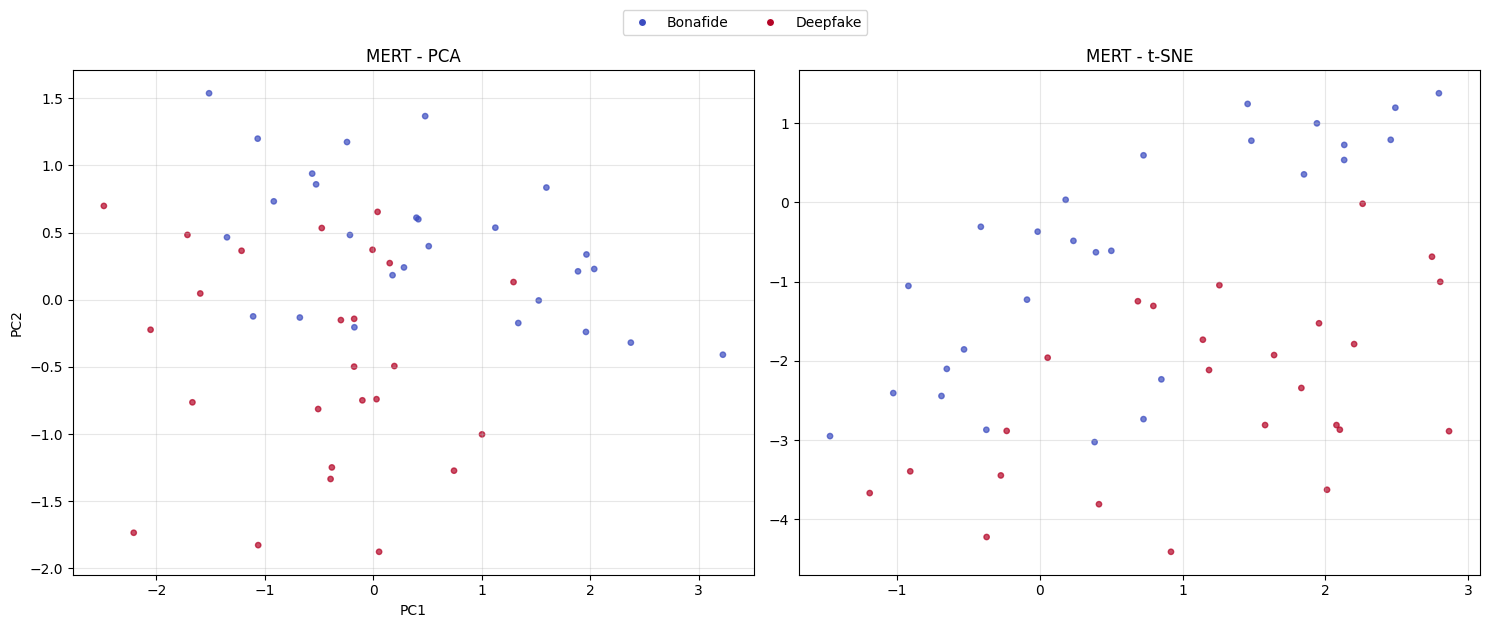

Loading Wav2Vec data (max 2000 samples)...


Loading Wav2Vec:   0%|          | 0/52 [00:00<?, ?it/s]

--- Data Diagnostics for Wav2Vec ---
Data shape: (52, 1024)
Labels shape: (52,)
Class distribution: [27 25] (0=Bonafide, 1=Deepfake)
Contains NaNs: False
Min value: -1.2076
Max value: 1.0817
Mean value: 0.0005


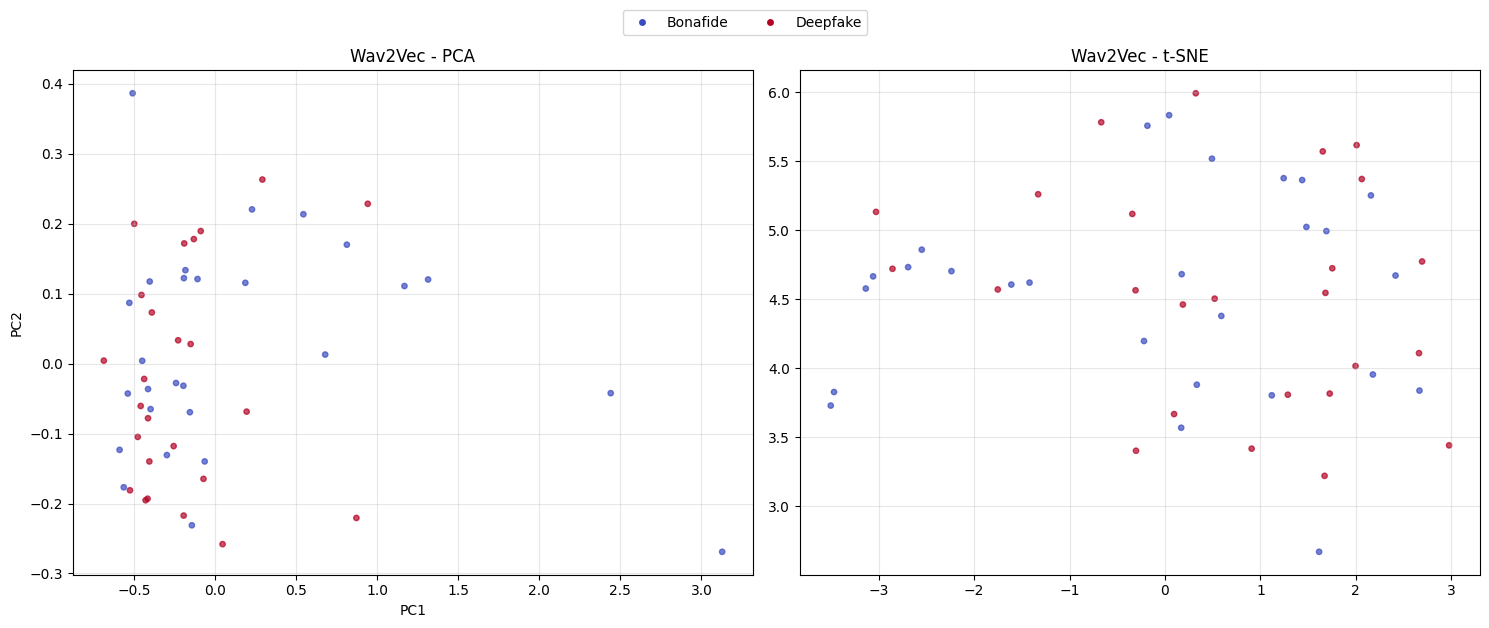

In [15]:
# 2. COMPARISON OF DIMENSIONS
print("\n--- Checking dimensions (first 5 samples) ---")
for i in range(min(5, len(mert_files))):
    m_path = mert_files[i]
    w_path = w2v / m_path.name
    
    if not w_path.exists():
        print(f"WARNING: Missing W2V file for {m_path.name}")
        continue
    
    try:
        # Infer class from name
        cls = "bonafide" if "bonafide" in m_path.name else "deepfake" if "deepfake" in m_path.name else "unknown"
        
        m_arr = np.load(str(m_path))
        w_arr = np.load(str(w_path))
        
        print(f"File: {m_path.name}")
        print(f"  Class: {cls}")
        print(f"  MERT shape:    {m_arr.shape}")
        print(f"  Wav2Vec shape: {w_arr.shape}")
        print("-" * 30)
    except Exception as e:
        print(f"Error loading {m_path.name}: {e}")

# 3. VISUALIZATION
print("\n--- Generating Plots ---")
load_and_visualize(mert_files, model_name="MERT")
load_and_visualize(w2v_files, model_name="Wav2Vec")

In [15]:
# Analiza "Too Good To Be True"
import numpy as np
from tqdm.notebook import tqdm

def check_feature_leakage(file_list, model_name="Model", limit=1000):
    bf_feats = []
    df_feats = []
    
    files_to_process = list(file_list)[:limit] # biorę pierwsze 'limit' plików
    
    for p in tqdm(files_to_process, desc=f"Analyzing {model_name}"):
        try:
            arr = np.load(str(p))
            # Średnia po czasie [Dim]
            mean_vec = np.mean(arr, axis=0)
            
            if "bonafide" in p.name:
                bf_feats.append(mean_vec)
            elif "deepfake" in p.name or "spoof" in p.name:
                df_feats.append(mean_vec)
        except Exception:
            pass

    bf = np.array(bf_feats)
    df = np.array(df_feats)
    
    if len(bf) == 0 or len(df) == 0:
        print(f"Skipping {model_name}: Not enough samples per class.")
        return

    # Policz średnią globalną dla klas
    mean_bf = np.mean(bf, axis=0)
    mean_df = np.mean(df, axis=0)
    
    # Różnica absolutna per cecha
    diff = np.abs(mean_bf - mean_df)
    
    max_diff_idx = np.argmax(diff)
    max_diff_val = diff[max_diff_idx]
    
    print(f"--- {model_name} Leakage Check ---")
    print(f"Max różnica średnich na cesze {max_diff_idx}: {max_diff_val:.4f}")
    
    # Sprawdź separowalność na tej jednej cesze
    bf_vals = bf[:, max_diff_idx]
    df_vals = df[:, max_diff_idx]
    
    print(f"Bonafide range: {bf_vals.min():.4f} to {bf_vals.max():.4f}")
    print(f"Deepfake range: {df_vals.min():.4f} to {df_vals.max():.4f}")
    
    if bf_vals.max() < df_vals.min() or df_vals.max() < bf_vals.min():
        print("!!! ALARM !!! Pełna separacja na JEDNYM wymiarze!")
    else:
        print("Brak trywialnej separacji na najlepszej cesze.")

# Uruchom dla MERT i W2V
print("Sprawdzam W2V...")
check_feature_leakage(w2v_files, model_name="Wav2Vec")
print("\nSprawdzam MERT...")
check_feature_leakage(mert_files, model_name="MERT")

Sprawdzam W2V...


Analyzing Wav2Vec:   0%|          | 0/1000 [00:00<?, ?it/s]

--- Wav2Vec Leakage Check ---
Max różnica średnich na cesze 371: 0.0970
Bonafide range: -1.2082 to -0.5620
Deepfake range: -1.2144 to -0.4863
Brak trywialnej separacji na najlepszej cesze.

Sprawdzam MERT...


Analyzing MERT:   0%|          | 0/1000 [00:00<?, ?it/s]

--- MERT Leakage Check ---
Max różnica średnich na cesze 229: 0.8866
Bonafide range: -1.6729 to 2.1678
Deepfake range: -1.9493 to 1.3333
Brak trywialnej separacji na najlepszej cesze.


In [10]:
random.seed(1)
data_dir = Path("/net/people/plgrid/plgjedrzejkusnierz/scratch/data/Sonics/all_data_16k_mono")
all_files = data_dir.iterdir()
bf_list = []
df_list = []
for f in all_files:
    name = f.stem
    bf_or_df = str(name).split("_")[-1]
    if bf_or_df == "bonafide":
        bf_list.append(f)
    elif bf_or_df == "deepfake":
        df_list.append(f)
    else:
        pass

In [11]:
print(len(bf_list))
print(len(df_list))

44141
49074


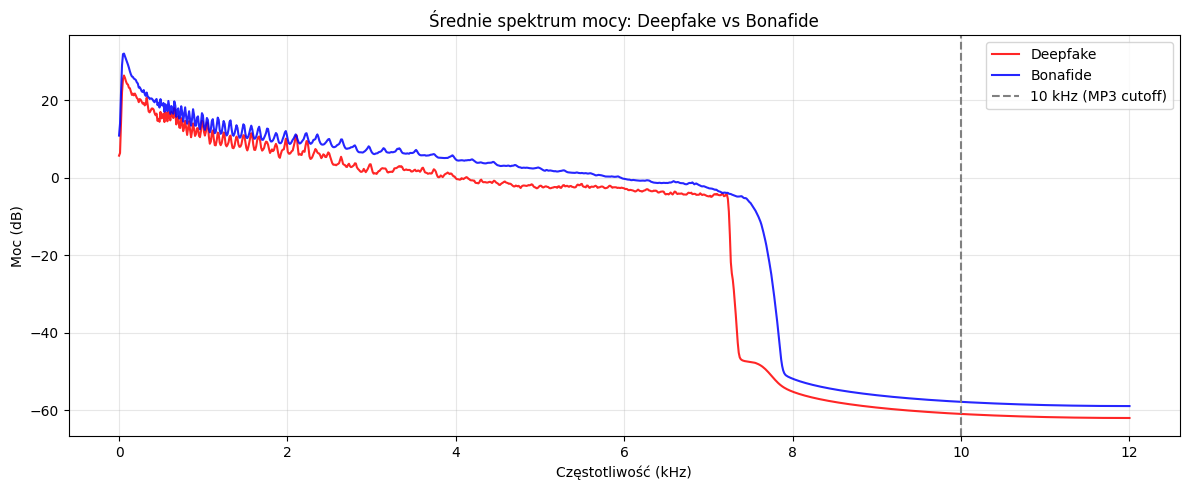

In [14]:

# bonafide_files = df_meta[df_meta['spoof'] == 'bonafide']['filepath'].dropna().tolist()
# deepfake_files  = df_meta[df_meta['spoof'] == 'deepfake']['filepath'].dropna().tolist()

N = 5000
bf_sample = random.sample(bf_list, min(N, len(bf_list)))
df_sample = random.sample(df_list,  min(N, len(df_list)))

SR = 24000
N_FFT = 2048
DURATION = 15.0  # pierwsze 15s wystarczy

def mean_power_spectrum(filepaths):
    spectra = []
    for fp in filepaths:
        try:
            y, _ = librosa.load(fp, sr=SR, duration=DURATION, mono=True)
            S = np.abs(librosa.stft(y, n_fft=N_FFT)) ** 2
            spectra.append(np.mean(S, axis=1))
        except Exception as e:
            print(f"skip {fp}: {e}")
    return np.mean(spectra, axis=0) if spectra else None

freqs = librosa.fft_frequencies(sr=SR, n_fft=N_FFT)
bf_spec = mean_power_spectrum(bf_sample)
df_spec = mean_power_spectrum(df_sample)

plt.figure(figsize=(12, 5))
plt.plot(freqs / 1000, 10 * np.log10(df_spec + 1e-10), label='Deepfake', color='red',  alpha=0.85)
plt.plot(freqs / 1000, 10 * np.log10(bf_spec + 1e-10), label='Bonafide', color='blue', alpha=0.85)
plt.axvline(x=10, color='gray', linestyle='--', label='10 kHz (MP3 cutoff)')
plt.xlabel('Częstotliwość (kHz)')
plt.ylabel('Moc (dB)')
plt.title('Średnie spektrum mocy: Deepfake vs Bonafide')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Energia >10kHz  |  Bonafide: 0.0000 ± 0.0000
Energia >10kHz  |  Deepfake: 0.0000 ± 0.0000


/net/afscra/people/plgjedrzejkusnierz/slurm_jobdir/19694937/tmp.ac0788/ipykernel_3672876/1458973047.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df_ratios, bf_ratios], labels=['Deepfake', 'Bonafide'], patch_artist=True,


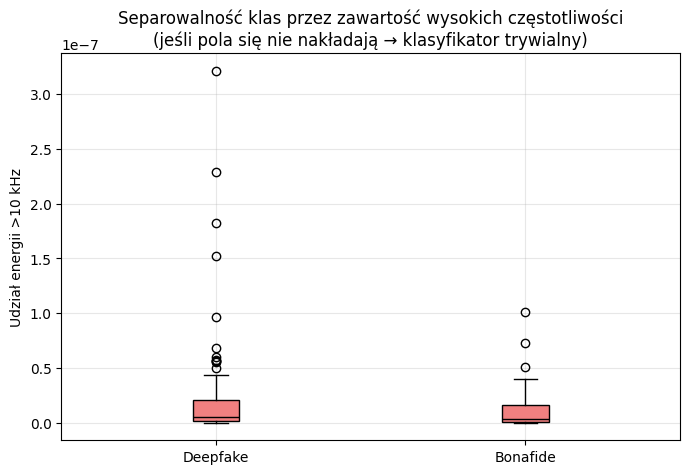

In [29]:
CUTOFF_HZ = 10_000
cutoff_bin = int(CUTOFF_HZ / (SR / N_FFT))

def hf_energy_ratio(filepaths):
    ratios = []
    for fp in filepaths:
        try:
            y, _ = librosa.load(fp, sr=SR, duration=DURATION, mono=True)
            S = np.abs(librosa.stft(y, n_fft=N_FFT)) ** 2
            mean_S = np.mean(S, axis=1)
            ratio = np.sum(mean_S[cutoff_bin:]) / (np.sum(mean_S) + 1e-10)
            ratios.append(ratio)
        except:
            pass
    return ratios

bf_ratios = hf_energy_ratio(bf_sample)
df_ratios = hf_energy_ratio(df_sample)

print(f"Energia >10kHz  |  Bonafide: {np.mean(bf_ratios):.4f} ± {np.std(bf_ratios):.4f}")
print(f"Energia >10kHz  |  Deepfake: {np.mean(df_ratios):.4f} ± {np.std(df_ratios):.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([df_ratios, bf_ratios], labels=['Deepfake', 'Bonafide'], patch_artist=True,
           boxprops=dict(facecolor='lightcoral'), medianprops=dict(color='black'))
ax.set_ylabel('Udział energii >10 kHz')
ax.set_title('Separowalność klas przez zawartość wysokich częstotliwości\n(jeśli pola się nie nakładają → klasyfikator trywialny)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
df_meta['duration'] = pd.to_numeric(df_meta['duration'], errors='coerce')
df_long = df_meta[df_meta['duration'] >= 120]
print(df_long.groupby('spoof').size())

spoof
bonafide    43098
deepfake    40821
dtype: int64


## Leakagage tests

In [10]:
dur = pd.to_numeric(df_meta['duration'], errors='coerce')
long_meta = df_meta.loc[dur >= 120].copy()

print(long_meta.groupby('spoof').size())

wanted = set(long_meta['filename'].str.replace('.flac', '', regex=False))

long_mert = [p for p in mert_files if p.stem in wanted]
long_w2v  = [p for p in w2v_files  if p.stem in wanted]

print(f"Pliki MERT >= 120s: {len(long_mert)}")
print(f"Pliki W2V  >= 120s: {len(long_w2v)}")

spoof
bonafide    43098
deepfake    40821
dtype: int64
Pliki MERT >= 120s: 83914
Pliki W2V  >= 120s: 83914


In [ ]:
random.seed(11)
random.shuffle(long_mert)


In [14]:
random.seed(11)
random.shuffle(long_w2v)

#### Caching data

In [ ]:
stems_mert = []
X_mert, y_mert = [], []
for p in tqdm(long_mert[:40000]):
    try:
        arr = np.load(str(p))
        X_mert.append(np.mean(arr, axis=0))
        y_mert.append(0 if "bonafide" in p.name else 1)
        stems_mert.append(p.stem)
    except: passs

X_mert = np.array(X_mert)
y_mert = np.array(y_mert)
stems_mert = np.array(stems_mert)

np.save(cache_dir / "X_mert_pooled.npy", X_mert)
np.save(cache_dir / "y_mert.npy", y_mert)
np.save(cache_dir / "stems_mert.npy", stems_mert)

  0%|          | 0/40000 [00:00<?, ?it/s]

In [ ]:
stems_w2v = []
X_w2v, y_w2v = [], []
for p in tqdm(long_w2v[:40000]):
    try:
        arr = np.load(str(p))
        X_w2v.append(np.mean(arr, axis=0))
        y_w2v.append(0 if "bonafide" in p.name else 1)
        stems_w2v.append(p.stem)
    except: pass

X_w2v = np.array(X_w2v)
y_w2v = np.array(y_w2v)
stems_w2v = np.array(stems_w2v)
np.save(cache_dir / "X_w2v_pooled.npy", X_w2v)
np.save(cache_dir / "y_w2v.npy", y_w2v)
np.save(cache_dir / "stems_w2v.npy", stems_w2v)

  0%|          | 0/40000 [00:00<?, ?it/s]

In [10]:
X_mert = np.load(cache_dir / "X_mert_pooled.npy")  # [83914, 1024]
y_mert = np.load(cache_dir / "y_mert.npy")          # [83914]
print(f"Loaded: {X_mert.shape}, klasy: {np.bincount(y_mert)}")

X_w2v = np.load(cache_dir / "X_w2v_pooled.npy")
y_w2v = np.load(cache_dir / "y_w2v.npy")          
print(f"Loaded: {X_w2v.shape}, klasy: {np.bincount(y_w2v)}")

Loaded: (40000, 1024), klasy: [20605 19395]
Loaded: (40000, 1024), klasy: [20600 19400]


In [ ]:
def leakage_test(X, y, model_name, limit=2000):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, C=1.0))
    ])
    auc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    print(f"  AUC: {auc.mean():.3f} ± {auc.std():.3f}")
    print(f"  Interpretacja: ", end="")
    if   auc.mean() > 0.85: print("SILNY leakage — model uczy się artefaktu")
    elif auc.mean() > 0.70: print("UMIARKOWANY leakage — ryzyko shortcut learning")
    elif auc.mean() > 0.60: print("SŁABY leakage — prawdopodobnie akceptowalny")
    else:                   print("brak leakage — OK")
    return auc.mean()

auc_mert = leakage_test(X_mert, y_mert, "MERT")
auc_w2v  = leakage_test(X_w2v, y_w2v, "WAV2VEC")

Loaded: (40000, 1024), klasy: [20605 19395]
Loaded: (40000, 1024), klasy: [20600 19400]


  AUC: 1.000 ± 0.000
  Interpretacja: SILNY leakage — model uczy się artefaktu
  AUC: 1.000 ± 0.000
  Interpretacja: SILNY leakage — model uczy się artefaktu


In [13]:
def sanity_check(file_list, model_name, limit=4000):
    X, y = [], []
    for p in list(file_list)[:limit]:
        try:
            arr = np.load(str(p))
            X.append(np.mean(arr, axis=0))
            y.append(0 if "bonafide" in p.name else 1)
        except: pass
    
    X, y = np.array(X), np.array(y)
    # Losowe etykiety
    y_random = np.random.permutation(y)
    
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    auc_real   = cross_val_score(pipe, X, y,        cv=cv, scoring='roc_auc').mean()
    auc_random = cross_val_score(pipe, X, y_random, cv=cv, scoring='roc_auc').mean()
    
    print(f"{model_name}: AUC prawdziwy={auc_real:.3f}, AUC losowy={auc_random:.3f}")
    print(f"  (losowy powinien być ~0.5 — jeśli nie, test ma bug)")

In [14]:
auc_mert = sanity_check(long_mert, "MERT")
auc_w2v  = sanity_check(long_w2v,  "WAV2VEC")

MERT: AUC prawdziwy=1.000, AUC losowy=0.498
  (losowy powinien być ~0.5 — jeśli nie, test ma bug)
WAV2VEC: AUC prawdziwy=1.000, AUC losowy=0.483
  (losowy powinien być ~0.5 — jeśli nie, test ma bug)


In [11]:
stems = np.load(cache_dir / "stems_mert.npy", allow_pickle=True)
stem_to_algo = dict(zip(
    df_meta['filename'].str.replace('.flac','', regex=False),
    df_meta['algorithm']
))
algos = np.array([stem_to_algo.get(s, '') for s in stems])

for algo in np.unique(algos[algos != '']):
    mask = (algos == algo) | (y_mert == 0)  # ten algo + wszystkie bonafide
    Xi, yi = X_mert[mask], y_mert[mask]
    if len(np.unique(yi)) < 2: continue
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
    auc = cross_val_score(pipe, Xi, yi, cv=5, scoring='roc_auc').mean()
    print(f"{algo:25s} | n={mask.sum():5d} | AUC={auc:.3f}")

chirp-v3                  | n=22183 | AUC=1.000
chirp-v3.5                | n=29538 | AUC=1.000
udio-120s                 | n=29489 | AUC=1.000


In [13]:
# Sprawdź jak długie są chirp-v2-xxl-alpha
print(df_meta[df_meta['algorithm'] == 'chirp-v2-xxl-alpha']['duration'].describe())

count    2084.000000
mean       79.703862
std         2.752482
min        39.132000
25%        80.100000
50%        80.100000
75%        80.100000
max        80.100000
Name: duration, dtype: float64


### 4 additional tests

#### Cross-algo generalization

In [14]:
stems_mert = np.load(cache_dir / "stems_mert.npy", allow_pickle=True)
stem_to_algo = dict(zip(
    df_meta['filename'].str.replace('.flac','', regex=False),
    df_meta['algorithm']
))
algos = np.array([stem_to_algo.get(s, '') for s in stems_mert])

# Test: train chirp-v3 → test udio, i odwrotnie
for train_algo, test_algo in [("chirp-v3", "udio-120s"), ("udio-120s", "chirp-v3")]:
    bf_mask   = (y_mert == 0)
    train_mask = (algos == train_algo) | bf_mask
    test_mask  = (algos == test_algo)  | bf_mask
    # żeby test set był rozłączny (bonafide użyj w obu, ale deepfake rozłącznie)
    train_mask = (algos == train_algo) | (bf_mask & (np.arange(len(y_mert)) % 2 == 0))
    test_mask  = (algos == test_algo)  | (bf_mask & (np.arange(len(y_mert)) % 2 == 1))

    Xtr, ytr = X_mert[train_mask], y_mert[train_mask]
    Xte, yte = X_mert[test_mask],  y_mert[test_mask]
    
    pipe = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
    pipe.fit(Xtr, ytr)
    from sklearn.metrics import roc_auc_score
    auc = roc_auc_score(yte, pipe.predict_proba(Xte)[:, 1])
    print(f"Train: {train_algo:15s} → Test: {test_algo:15s} | AUC={auc:.3f}")

Train: chirp-v3        → Test: udio-120s       | AUC=1.000
Train: udio-120s       → Test: chirp-v3        | AUC=1.000


#### MFCC baseline

In [15]:
import librosa

def compute_mfcc_mean(filepath, sr=16000, n_mfcc=40, duration=30.0):
    y, _ = librosa.load(filepath, sr=sr, duration=duration, mono=True)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfcc, axis=1)  # [40]

data_dir = Path("/net/people/plgrid/plgjedrzejkusnierz/scratch/data/Sonics/all_data_16k_mono")

X_mfcc, y_mfcc = [], []
files = list(data_dir.glob("*.flac"))
random.seed(42); random.shuffle(files)

for p in tqdm(files[:4000]):
    try:
        feat = compute_mfcc_mean(p)
        label = 0 if "bonafide" in p.name else 1
        X_mfcc.append(feat)
        y_mfcc.append(label)
    except: pass

X_mfcc, y_mfcc = np.array(X_mfcc), np.array(y_mfcc)
pipe = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
auc = cross_val_score(pipe, X_mfcc, y_mfcc, cv=5, scoring='roc_auc').mean()
print(f"MFCC (raw audio) AUC={auc:.3f}")

  0%|          | 0/4000 [00:00<?, ?it/s]

MFCC (raw audio) AUC=0.999


#### official train-test split

In [17]:
from sklearn.metrics import roc_auc_score

stems_mert = np.load(cache_dir / "stems_mert.npy", allow_pickle=True)
stem_to_set = dict(zip(
    df_meta['filename'].str.replace('.flac','', regex=False),
    df_meta['set']
))
sets = np.array([stem_to_set.get(s, '') for s in stems_mert])

tr = sets == 'train'
te = sets == 'test'

pipe = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
pipe.fit(X_mert[tr], y_mert[tr])
auc = roc_auc_score(y_mert[te], pipe.predict_proba(X_mert[te])[:, 1])
print(f"Official train→test AUC: {auc:.3f}")

Official train→test AUC: 1.000


#### dimensions to separate

In [16]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_mert, y_mert, random_state=42)
print(f"Liczba wymiarów z MI>0.1: {(mi > 0.1).sum()}")
print(f"Liczba wymiarów z MI>0.5: {(mi > 0.5).sum()}")

for k in [1, 5, 10, 50, 100, 256]:
    top_dims = np.argsort(mi)[-k:]
    auc = cross_val_score(
        Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
        X_mert[:, top_dims], y_mert, cv=5, scoring='roc_auc'
    ).mean()
    print(f"Top-{k:4d} dims: AUC={auc:.3f}")

Liczba wymiarów z MI>0.1: 305
Liczba wymiarów z MI>0.5: 1
Top-   1 dims: AUC=0.979
Top-   5 dims: AUC=0.999
Top-  10 dims: AUC=1.000
Top-  50 dims: AUC=1.000
Top- 100 dims: AUC=1.000
Top- 256 dims: AUC=1.000


#### checking one dimension

Najbardziej dyskryminujący wymiar: 746, MI=0.507


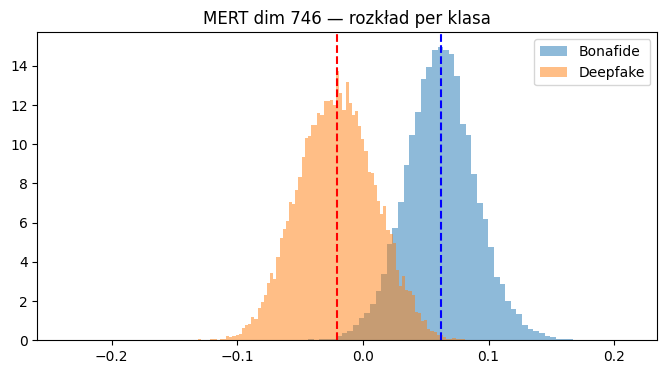

Bonafide mean: 0.062 ± 0.028
Deepfake mean: -0.021 ± 0.030


In [18]:
mi = mutual_info_classif(X_mert, y_mert, random_state=42)
best_dim = np.argmax(mi)
print(f"Najbardziej dyskryminujący wymiar: {best_dim}, MI={mi[best_dim]:.3f}")

# Rozkład wartości per klasa
bf_vals = X_mert[y_mert==0, best_dim]
df_vals = X_mert[y_mert==1, best_dim]

plt.figure(figsize=(8, 4))
plt.hist(bf_vals, bins=100, alpha=0.5, label='Bonafide', density=True)
plt.hist(df_vals, bins=100, alpha=0.5, label='Deepfake', density=True)
plt.axvline(np.mean(bf_vals), color='blue', linestyle='--')
plt.axvline(np.mean(df_vals), color='red', linestyle='--')
plt.legend()
plt.title(f'MERT dim {best_dim} — rozkład per klasa')
plt.show()

print(f"Bonafide mean: {np.mean(bf_vals):.3f} ± {np.std(bf_vals):.3f}")
print(f"Deepfake mean: {np.mean(df_vals):.3f} ± {np.std(df_vals):.3f}")

In [25]:
import os
os.environ["PATH"] = "/net/software/testing/software/mace-torch/0.3.14/bin:" + os.environ["PATH"]

# Sprawdź
import subprocess
result = subprocess.run(["ffmpeg", "-version"], capture_output=True, text=True)
print(result.stdout[:100])

ffmpeg version 4.2.2 Copyright (c) 2000-2019 the FFmpeg developers
built with gcc 7.3.0 (crosstool-N


In [29]:
import subprocess, tempfile, os

def double_compress_bonafide(src_flac: Path, target_kbps=38) -> np.ndarray:
    """Symuluje prior compression: FLAC → {target_kbps}kbps MP3 → 32kbps MP3 → 16kHz PCM → MFCC"""
    with tempfile.TemporaryDirectory() as tmp:
        mp3_1 = os.path.join(tmp, "prior.mp3")
        mp3_2 = os.path.join(tmp, "final.mp3")
        out_flac = os.path.join(tmp, "out.flac")
        # Symuluj prior compression (jak Suno/Udio)
        subprocess.run(["ffmpeg", "-y", "-hide_banner", "-loglevel", "error",
                        "-i", str(src_flac), "-b:a", f"{target_kbps}k", mp3_1], check=True)
        # Nasz standardowy pipeline
        subprocess.run(["ffmpeg", "-y", "-hide_banner", "-loglevel", "error",
                        "-i", mp3_1, "-b:a", "32k", mp3_2], check=True)
        subprocess.run(["ffmpeg", "-y", "-hide_banner", "-loglevel", "error",
                        "-i", mp3_2, "-ar", "16000", out_flac], check=True)
        y, _ = librosa.load(out_flac, sr=16000, duration=30.0, mono=True)
        return librosa.feature.mfcc(y=y, sr=16000, n_mfcc=40).mean(axis=1)

# Wezm 200 bonafide
orig_dir = Path("/net/people/plgrid/plgjedrzejkusnierz/scratch/data/Sonics/all_data")
orig_bf = list(orig_dir.glob("*bonafide*.flac"))
random.seed(42); random.shuffle(orig_bf)

X_dc, y_dc = [], []
for p in tqdm(orig_bf[:200]):
    try:
        feat = double_compress_bonafide(p, target_kbps=38)
        print(feat)
        X_dc.append(feat)
        y_dc.append(0)  # to są bonafide — co powie klasyfikator?
    except: pass

X_dc = np.array(X_dc)

# Klasyfikator trenowany na oryginalnych danych
pipe_mfcc = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
pipe_mfcc.fit(X_mfcc, y_mfcc)

preds = pipe_mfcc.predict_proba(X_dc)[:, 1]
print(f"Średni p(deepfake) dla double-compressed bonafide: {preds.mean():.3f}")
print(f"Skrajności: min={preds.min():.3f}, max={preds.max():.3f}")
print(f"Klasyfikowanych jako deepfake (p>0.5): {(preds > 0.5).mean()*100:.1f}%")

  0%|          | 0/200 [00:00<?, ?it/s]

[-6.0845707e+01  1.3934015e+02 -4.9546722e+01  8.7126945e+01
 -2.7198410e+01  2.6094810e+01 -1.7408360e+00  1.6490911e+01
 -2.4147861e+00  7.3380342e+00  3.1727319e+00  7.9562181e-01
  4.0405366e-01 -4.7287407e+00  6.2958016e+00 -7.0493526e+00
  8.8296404e+00 -6.3488350e+00 -3.0182152e+00 -6.1086087e+00
  7.1025334e-02 -3.5784292e+00 -3.9954796e+00 -1.3762724e+00
 -5.6206522e+00  2.1201134e+00 -5.6215830e+00 -6.6748059e-01
  6.4111745e-01 -1.9738144e+00 -5.3256998e+00 -1.2818007e+00
 -2.5895610e+00 -3.4664137e+00 -2.9561682e+00 -1.2837839e+00
  4.5847840e+00 -2.3844903e+00 -2.2626021e+00 -2.0725462e+00]
[-2.6963998e+02  1.6918733e+02  5.4609418e-01  3.3565002e+01
  1.0789200e+01  2.5595758e+00  5.2094617e+00  4.8532276e+00
 -6.0289063e+00  6.7966032e-01 -5.1308813e+00 -5.8162074e+00
 -3.5380015e+00 -1.1612707e+00 -1.4476111e+00 -2.1966872e+00
  3.4452293e+00 -2.1452653e+00 -1.2136083e+00 -2.1915238e+00
 -1.0233711e+00 -2.5406466e+00  2.5289795e-01 -4.0092120e+00
 -4.4609475e+00 -2.5316

### Filtering idk

In [ ]:
random.seed(42)


bf_paths = random.sample(
    df_meta[df_meta['spoof'] == 'bonafide']['filepath'].dropna().tolist(), 10
)
df_paths = random.sample(
    df_meta[df_meta['spoof'] == 'deepfake']['filepath'].dropna().tolist(), 10
)

SAMPLE_RATE = 24000
LOWPASS_HZ  = 7000
N_FFT       = 2048
DURATION    = 15.0  # pierwsze 15s

def load_and_filter(filepath):
    """Ładuje audio i aplikuje dokładnie ten sam filtr co preprocessing."""
    wav, sr = torchaudio.load(filepath)
    # mono
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    # resample do 24kHz
    if sr != SAMPLE_RATE:
        wav = T.Resample(sr, SAMPLE_RATE)(wav)
    # brick-wall lowpass przy 7kHz (identyczny jak w preprocessingu)
    target_sr = LOWPASS_HZ * 2
    wav = T.Resample(SAMPLE_RATE, target_sr)(wav)
    wav = T.Resample(target_sr, SAMPLE_RATE)(wav)
    # przytnij do DURATION sekund
    max_samples = int(DURATION * SAMPLE_RATE)
    wav = wav[:, :max_samples].squeeze().numpy()
    return wav

def mean_spectrum(paths):
    spectra = []
    for p in paths:
        try:
            wav = load_and_filter(p)
            S = np.abs(librosa.stft(wav, n_fft=N_FFT)) ** 2
            spectra.append(np.mean(S, axis=1))
        except Exception as e:
            print(f"skip {p}: {e}")
    return np.mean(spectra, axis=0)

print("Liczę spektra...")
freqs = librosa.fft_frequencies(sr=SAMPLE_RATE, n_fft=N_FFT)
bf_spec = mean_spectrum(bf_paths)
df_spec = mean_spectrum(df_paths)

# --- Wykres 1: pełne pasmo 0–7kHz po filtrze ---
mask = freqs <= 7000
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(freqs[mask] / 1000,
             10 * np.log10(df_spec[mask] + 1e-10),
             label='Deepfake', color='red',  alpha=0.85)
axes[0].plot(freqs[mask] / 1000,
             10 * np.log10(bf_spec[mask] + 1e-10),
             label='Bonafide', color='blue', alpha=0.85)
axes[0].set_xlabel('Częstotliwość (kHz)')
axes[0].set_ylabel('Moc (dB)')
axes[0].set_title('Spektrum 0–7kHz po lowpass filtrze\n(czy nadal są różnice?)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Wykres 2: różnica między klasami w dB ---
diff = 10 * np.log10(bf_spec[mask] + 1e-10) - 10 * np.log10(df_spec[mask] + 1e-10)
axes[1].plot(freqs[mask] / 1000, diff, color='green')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].fill_between(freqs[mask] / 1000, diff, 0,
                     where=(diff > 0), color='blue', alpha=0.2, label='Bonafide silniejszy')
axes[1].fill_between(freqs[mask] / 1000, diff, 0,
                     where=(diff < 0), color='red',  alpha=0.2, label='Deepfake silniejszy')
axes[1].set_xlabel('Częstotliwość (kHz)')
axes[1].set_ylabel('Różnica (dB)')
axes[1].set_title('Różnica spektralna Bonafide − Deepfake\n(0 = identyczne, >0 = bonafide głośniejszy)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Liczba: czy różnica jest duża? ---
mean_diff = np.abs(diff).mean()
max_diff  = np.abs(diff).max()
print(f"Średnia różnica w 0–7kHz: {mean_diff:.1f} dB")
print(f"Maksymalna różnica:       {max_diff:.1f} dB")
print()
print("Interpretacja:")
print(f"  < 3 dB  → spektra bardzo podobne, leakage NIE jest spektralny")
print(f"  3–10 dB → umiarkowane różnice spektralne")
print(f"  > 10 dB → duże różnice — leakage nadal spektralny w 0–7kHz")